# 1.데이터분석_단변량분석

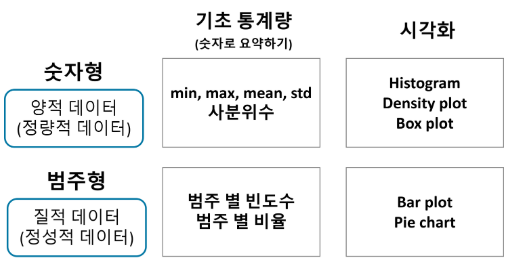

## 1.1.환경준비

### **1.1.1. 라이브러리 불러오기**

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **1.1.2. 데이터 로딩**

**1) titanic**

- 데이터 : titanic_simple.csv

**[titanic_simple 데이터 셋 정보]**

- PassengerId : 승객번호
- Survived : 생존여부(1:생존, 0:사망)
- Pclass : 객실등급(1:1등급, 2:2등급, 3:3등급)
- Name : 승객이름
- Sex : 성별(male, female)
- Age : 나이
- Fare : 운임($)
- Embarked : 승선지역(Southhampton, Cherbourg, Queenstown)

In [59]:
path = './data/titanic_simple.csv'
titanic = pd.read_csv(path)

titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,Southampton
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,Cherbourg
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250,Southampton
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,Southampton
4,5,0,3,"Allen, Mr. William Henry",male,35.0,8.0500,Southampton


In [60]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   Fare         891 non-null    float64
 7   Embarked     889 non-null    str    
dtypes: float64(2), int64(3), str(3)
memory usage: 55.8 KB


**2) New York Air Quality**

- airquality2.csv

**[airquality 데이터 셋 정보]**

- Ozone: 오존 농도  
- Solar.R: 태양복사량
- Wind: 풍속
- Temp: 기온
- Date : 연,월,일

In [61]:
path2 = './data/airquality2.csv'
air = pd.read_csv(path2)

air.tail()

,Ozone,Solar.R,Wind,Temp,Date
148,30,193.0,6.9,70,1973-09-26
149,23,145.0,13.2,77,1973-09-27
150,14,191.0,14.3,75,1973-09-28
151,18,131.0,8.0,76,1973-09-29
152,20,223.0,11.5,68,1973-09-30


In [62]:
air.info()

<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ozone    153 non-null    int64  
 1   Solar.R  146 non-null    float64
 2   Wind     153 non-null    float64
 3   Temp     153 non-null    int64  
 4   Date     153 non-null    str    
dtypes: float64(2), int64(2), str(1)
memory usage: 6.1 KB


## 1.2.숫자형 변수

### 1.2.1. 수치화 : 기초통계량

**1) 평균(산술평균)**

- 데이터를 모두 더한 뒤, 데이터의 개수로 나눈 값

- 데이터를 대표하는 **중심 경향성(central tendency)** 을 나타냄

- 이상치에 매우 민감함

In [63]:
# 순수한 NumPy 배열일 때 nan 결과 출력
a = np.array([1, 2, np.nan])
np.mean(a)

np.float64(nan)

In [64]:
# 넘파이 함수 이용하기 : NaN 값을 처리하지 않지만 속도 빠름
# 판다스 mean 메서드를 이용하기 : NaN을 자동으로 제외하고 평균
print(np.mean(titanic['Age']))
print(titanic['Age'].mean())

29.69911764705882
29.69911764705882


**2) 중앙값(중위수, median)**

- 데이터를 크기 순으로 정렬했을 때, **가운데에 위치한 값**

- 데이터의 개수가 **홀수**이면 가운데 값이 중앙값

- 데이터의 개수가 **짝수**이면 가운데 두 값의 평균이 중앙값

- 이상치에 거의 영향을 받지 않음

In [65]:
print(titanic['Fare'].median())

14.4542


In [66]:
# 넘파이 함수
np.median(titanic['Fare'])

np.float64(14.4542)

**3) 최빈값**

- 데이터셋에서 가장 자주 등장하는 값(빈도가 높은 값)

- 최빈값은 하나일 수도 있고, 여러 개일 수도 있음

- 이산형 데이터(셀 수 있는 데이터)

In [67]:
titanic['Pclass'].mode()

0    3
Name: Pclass, dtype: int64

**4) 4분위수**

- 데이터를 4개의 동일한 부분으로 나누는 기준 값

- 데이터셋을 오름차순으로 정렬한 후 4개의 부분으로 나눔

- 각 구간은 25%씩 동일한 비율로 데이터를 나눔


![](https://mblogthumb-phinf.pstatic.net/20150702_229/jevida_1435803723327eyeeG_PNG/3.png?type=w2)

In [68]:
titanic['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

**<연습문제>**

[문1] titanic의 Age에 대해서 다음을 각각 확인해 봅시다.

In [69]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,Southampton
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,Cherbourg
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250,Southampton
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,Southampton
4,5,0,3,"Allen, Mr. William Henry",male,35.0,8.0500,Southampton


In [70]:
# 평균
print(titanic['Age'].mean())

# 최빈값
print(titanic['Age'].mode())

# 중앙값
print(titanic.Age.median())  

# 4분위수
print(titanic['Age'].describe())

29.69911764705882
0    24.0
Name: Age, dtype: float64
28.0
count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64


[문2] air의 Ozone에 대해서 다음을 각각 확인해 봅시다.

In [71]:
# 평균
print(air['Ozone'].mean())

# 최빈값
print(air['Ozone'].mode())

# 중앙값
print(air['Ozone'].median())

# 4분위수
print(air['Ozone'].describe())

42.052287581699346
0    23
Name: Ozone, dtype: int64
34.0
count    153.000000
mean      42.052288
std       30.156127
min        1.000000
25%       20.000000
50%       34.000000
75%       59.000000
max      168.000000
Name: Ozone, dtype: float64


**5) describe()**

In [72]:
# 시리즈.describe()
titanic['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [73]:
# Transpose : 전치
# 행과 열을 서로 뒤바꾸는 기능을 수행
titanic[['Fare']].describe().T

,count,mean,std,min,25%,50%,75%,max
Fare,891.0,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


In [74]:
# 데이터프레임의 전체 변수들 기초통계량 조회
titanic.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,Fare,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,Southampton
freq,NaN,NaN,NaN,1,577,NaN,NaN,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,32.204208,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,49.693429,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,7.910400,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,14.454200,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,31.000000,NaN


**<연습문제>**

[문1] air 데이터프레임에 대해서 기초 통계량을 구하고, 내용을 파악해 봅시다.

In [75]:
air.describe()

,Ozone,Solar.R,Wind,Temp
count,153.000000,146.000000,153.000000,153.000000
mean,42.052288,185.931507,9.957516,77.882353
std,30.156127,90.058422,3.523001,9.465270
min,1.000000,7.000000,1.700000,56.000000
25%,20.000000,115.750000,7.400000,72.000000
50%,34.000000,205.000000,9.700000,79.000000
75%,59.000000,258.750000,11.500000,85.000000
max,168.000000,334.000000,20.700000,97.000000


### 1.2.2. 시각화

**1) 히스토그램**

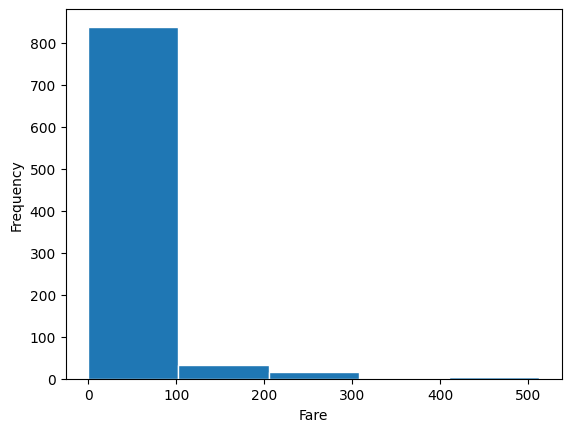

In [76]:
plt.hist(
    titanic['Fare'],
    bins=5,
    edgecolor='w'
)

plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

* 구간의 갯수를 조정해 봅시다.

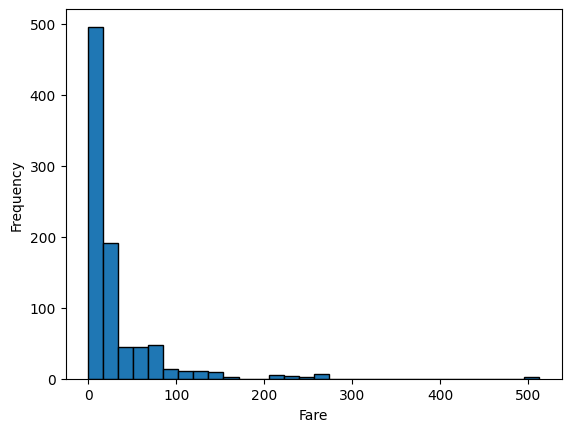

In [77]:
plt.hist(
    titanic['Fare'],
    bins=30,
    edgecolor='black'
)

plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

* sns.histplot

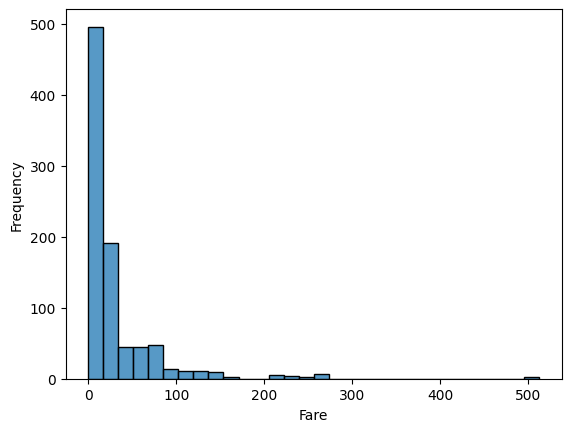

In [78]:
sns.histplot(
    x = 'Fare',
    data=titanic,
    bins=30
)
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

- bins에 따른 차이?

    - bins의 개수가 너무 작을 때
        - 막대(구간)의 개수가 너무 적어서 데이터의 **세부적인 분포를 파악하기 어려움**
        - 데이터의 패턴이나 트렌드가 **뭉뚱그려져** 보임
        - 장점 : 대략적인 데이터 분포는 파악할 수 있음
        - 단점 : 중요한 세부 정보가 손실될 수 있고, 데이터의 **세부적인 특징이 사라짐**

    - bins의 개수가 너무 많을 때
        - 막대(구간)의 개수가 너무 많아 데이터가 **과도하게 세분화**됨
        - 각 막대가 너무 좁아서 **노이즈(Noise)** 가 강조될 수 있음
        - 장점 : 아주 세밀한 패턴과 변화를 관찰할 수 있음
        - 단점 : 불필요한 세부사항이 강조될 수 있으며, 해석이 어려워질 수 있음

* (추가) 구간 값과 갯수를 확인

    * 결과를 저장하면, 구간과 빈도수를 확인할 수 있다.
        * 히스토그램을 저장하면 튜플
        * 튜플 안에는 넘파이 array가 2개로 구성됨
        * 첫번째 넘파이 array는 빈도수
        * 두번째는 구간 경계 값


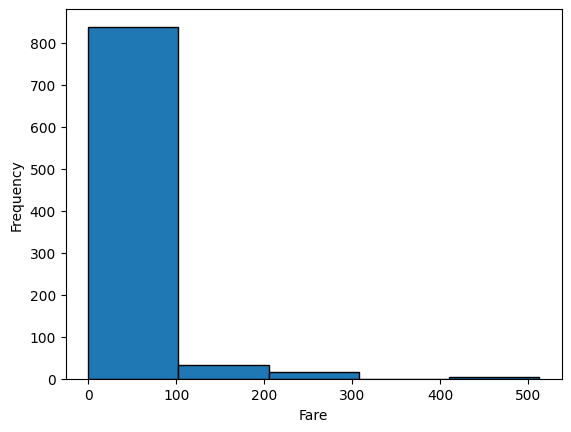

(array([838.,  33.,  17.,   0.,   3.]), array([  0.     , 102.46584, 204.93168, 307.39752, 409.86336, 512.3292 ]), <BarContainer object of 5 artists>)
<class 'tuple'>
빈도수: [838.  33.  17.   0.   3.]
구간 경계값: [  0.      102.46584 204.93168 307.39752 409.86336 512.3292 ]


In [79]:
hist1 = plt.hist(
        titanic['Fare'],
        bins=5,
        edgecolor='black'
)

plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

print(hist1)
print(type(hist1))
print('='*50)
print('빈도수:', hist1[0])
print('구간 경계값:', hist1[1] )

**<연습문제>**

[문1] titanic의 Age에 칼럼에 대해 히스토그램을 그려 봅시다.
* bins = 8, 16, 32, 64

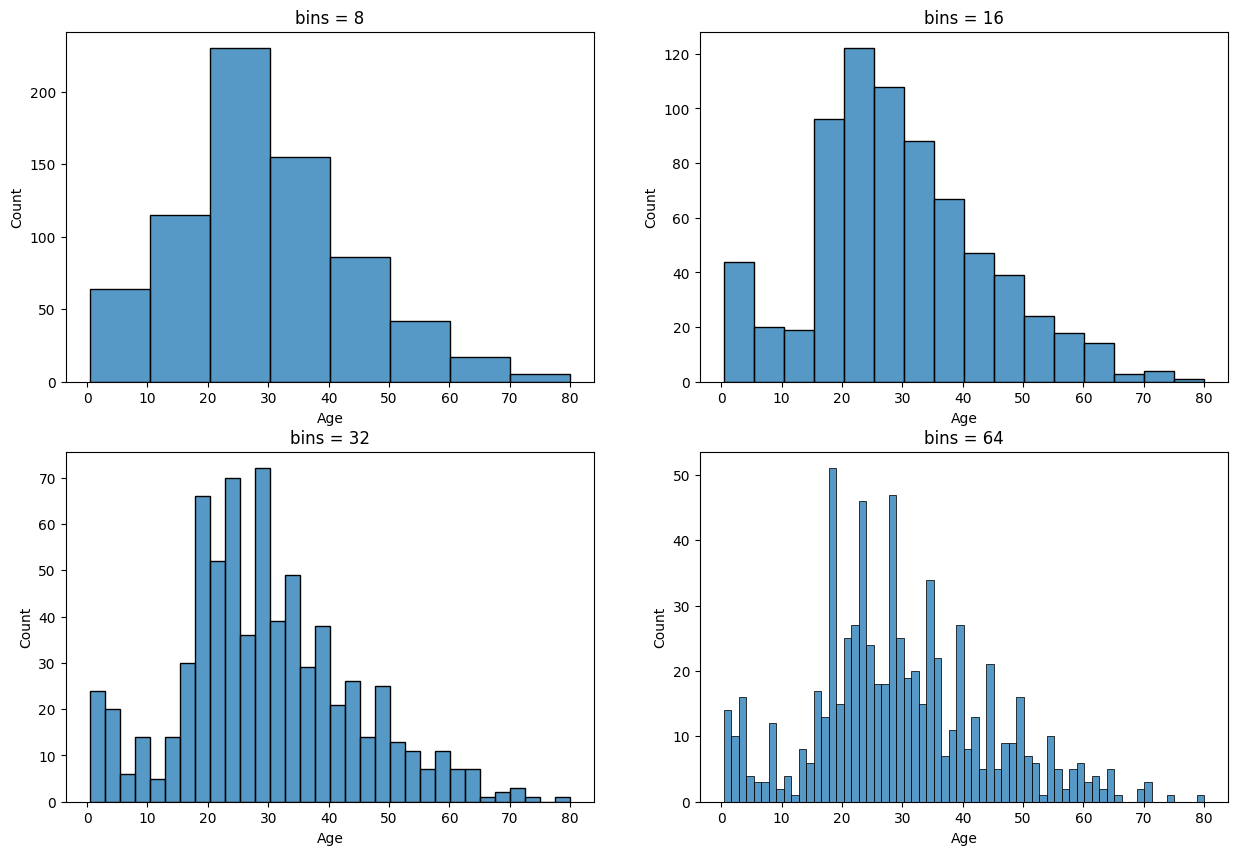

In [80]:
# 노가다
plt.figure(figsize=(15,10))

plt.subplot(2, 2, 1)
sns.histplot(x='Age', data=titanic, bins=8)
plt.title(f'bins = 8')

plt.subplot(2, 2, 2)
sns.histplot(x='Age', data=titanic, bins=16)
plt.title(f'bins = 16')

plt.subplot(2, 2, 3)
sns.histplot(x='Age', data=titanic, bins=32)
plt.title(f'bins = 32')

plt.subplot(2, 2, 4)
sns.histplot(x='Age', data=titanic, bins=64)
plt.title(f'bins = 64')

plt.show()

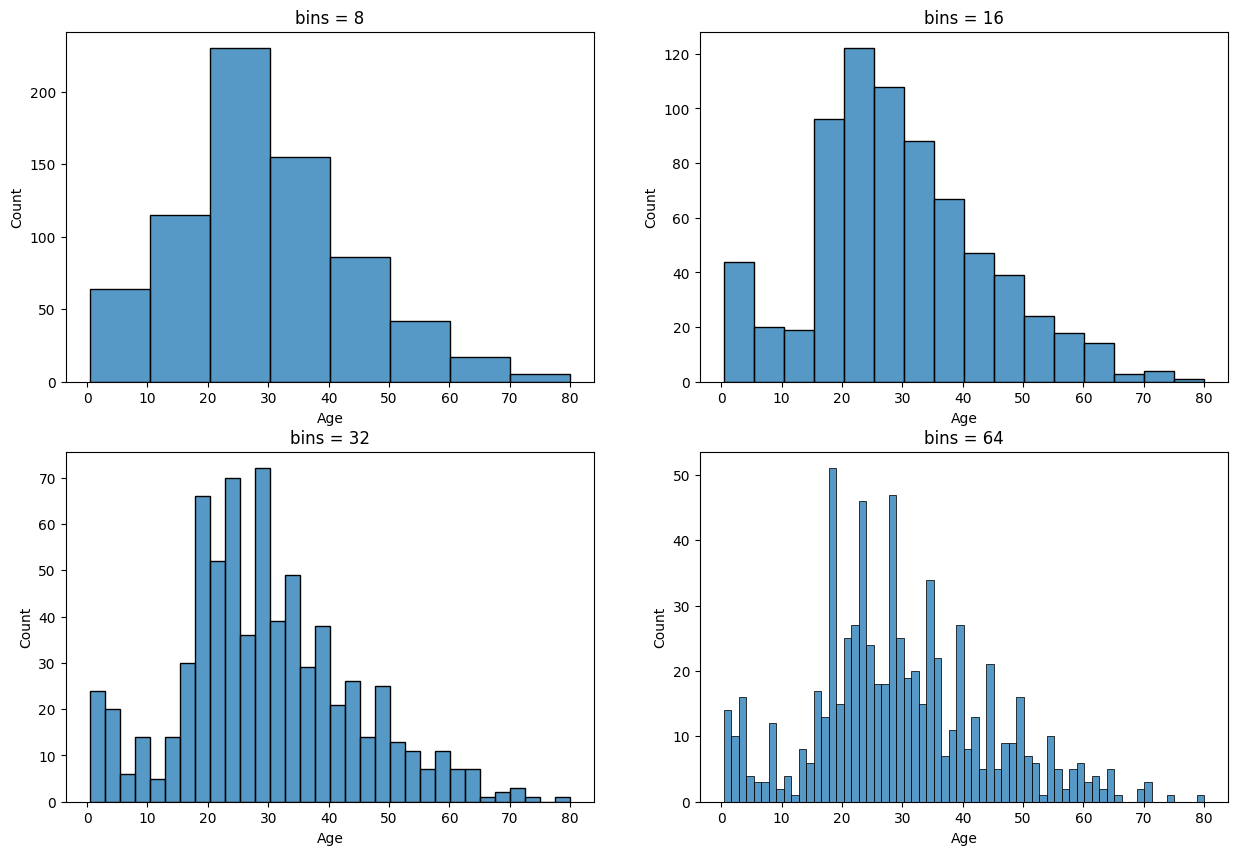

In [81]:
bins = [8,16,32,64]

plt.figure(figsize=(15,10))

for i, bin in enumerate(bins):
    plt.subplot(2, 2, i + 1)
    sns.histplot(x='Age', data=titanic, bins=bin)
    plt.title(f'bins = {bin}')

plt.show()

**2) 밀도함수 그래프(kde plot)**

* 히스토그램의 단점
    * 구간(bin)의 너비를 어떻게 잡는지에 따라 전혀 다른 모양이 될 수 있음

* 밀도함수 그래프
    * 막대의 너비를 가정하지 않고 모든 점에서 데이터의 밀도를 추정하는 커널 밀도 추정(Kernel Density Estimation)방식을 사용하여 이러한 단점을 해결.
    * 밀도함수 그래프 아래 면적은 1

* 밀도함수 그래프 그리기

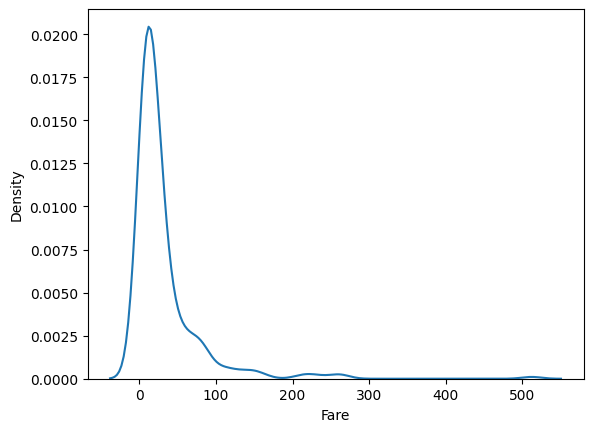

In [82]:
sns.kdeplot(x='Fare', data=titanic)
plt.show()

- 밀도 추정
    - 측정된(관측된) 데이터로부터 전체 데이터 분포의 특성을 추정
    - 예를 들어... 한 웹사이트의 일일 방문자수를 측정한다고 해 보자.
        - 어제는 1200명이 방문했고, 오늘은 1620명, 내일은, 모레는...
        - 이렇게 6개월간 매일 측정했다고 할 때,
        - 우리는 약 180일치의 데이터를 가지고 일일 방문자 수 분포를 히스토그램으로 그려볼 수 있다.
        - 그리고 나서 특정한 날의 방문자수가 얼마나 될지 확률로 나타냄



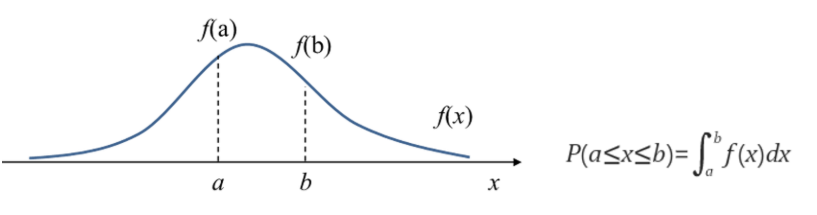

**<연습문제>**

[문1] titanic Age에 대해서 밀도함수 그래프를 그려봅시다.  

히스토그램과 어떤 차이가 있는가?

- 히스토그램
    - 구간을 나눠서 개수를 셈
    - 직관적이고 쉬움
    - bin 설정에 따라 모양이 달라짐
- KED
    - 부드러운 곡선으로 분포 추정
    - 매끄럽지만 실제 개수 느낌은 덜 직접적임.

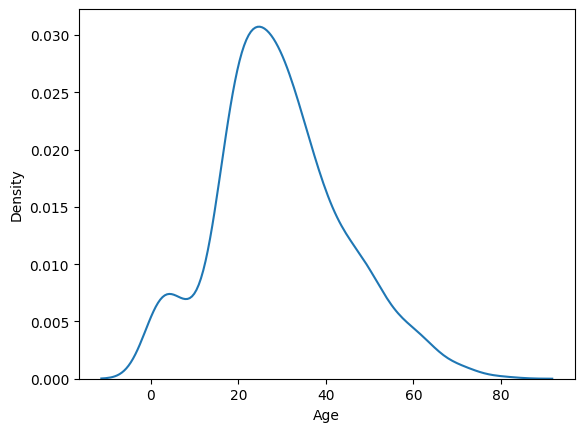

In [83]:
sns.kdeplot(x='Age', data=titanic)
plt.show()

[문2] titanic Age에 대해서 히스토그램을 그려봅시다.
* 단, 이번에는 sns.histplot 을 이용한다.
* 옵션으로 kde = True 를 지정해 보자.

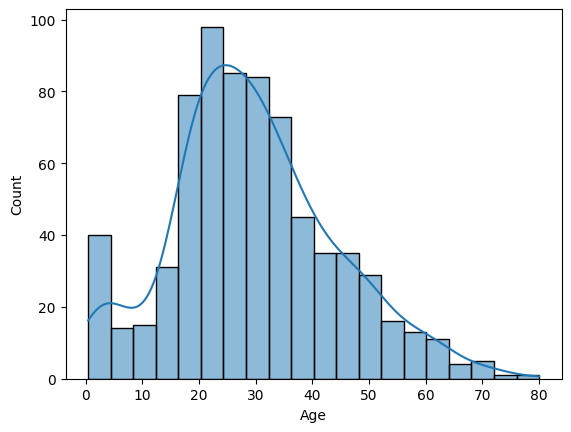

In [84]:
sns.histplot(x='Age', data=titanic, kde=True)
plt.show()

**3) boxplot**

- **주의사항** : 값에 **NaN**이 있으면 그래프가 그려지지 않는다.

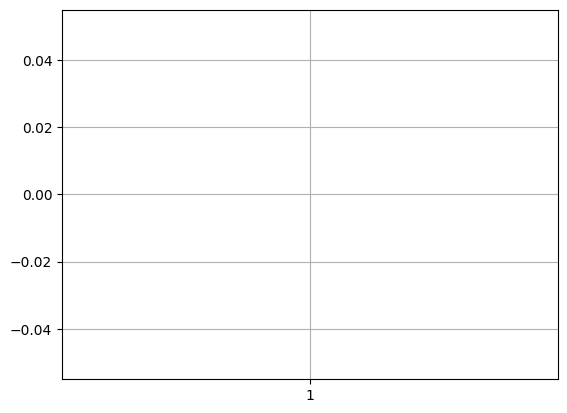

In [85]:
plt.boxplot(titanic['Age'])
plt.grid()
plt.show()

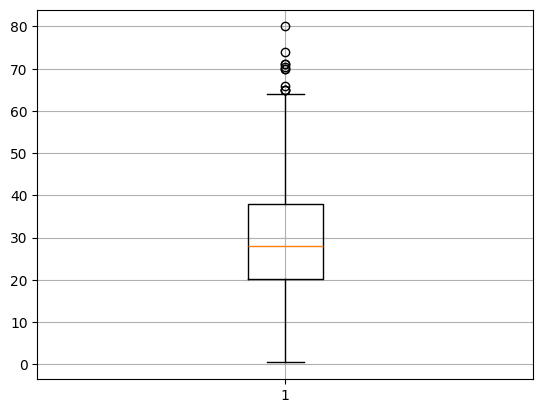

In [86]:
# 결측치 처리
temp = titanic.loc[titanic['Age'].notna()]

plt.boxplot(temp['Age'])
plt.grid()
plt.show()

* 옆으로 그리기

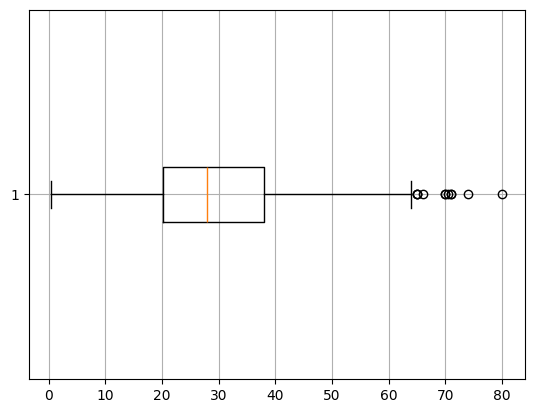

In [87]:
plt.boxplot(temp['Age'], vert=False)
plt.grid()
plt.show()

* sns.boxplot
    * seaborn 패키지 함수들은 NaN을 알아서 빼고 그려준다.

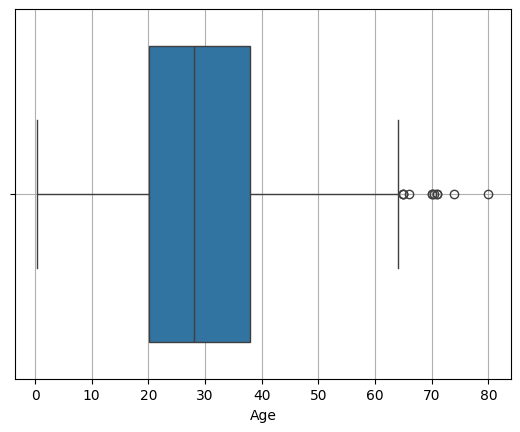

In [88]:
sns.boxplot(x=titanic['Age'])
plt.grid()
plt.show()

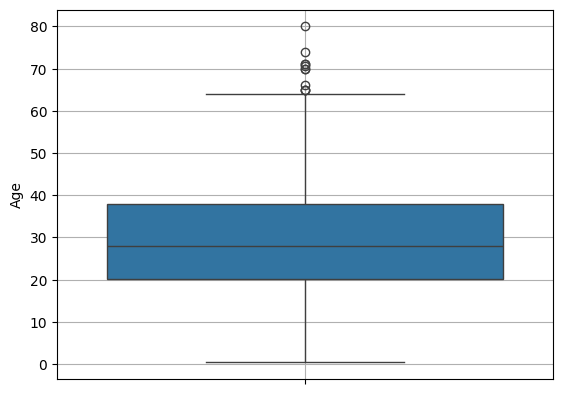

In [89]:
sns.boxplot(y=titanic['Age'])
plt.grid()
plt.show()

**박스플롯의 의미**

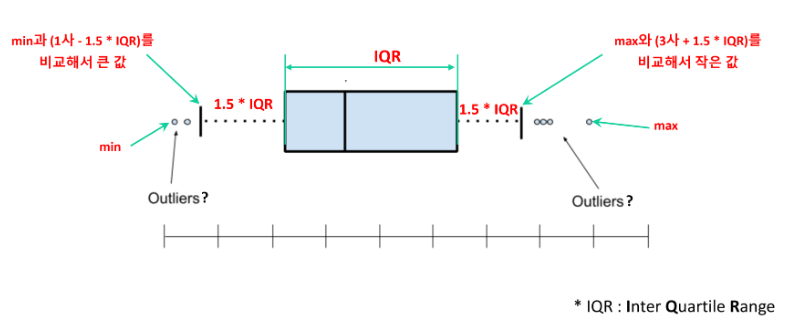

* (추가) 박스플롯의 값들 확인

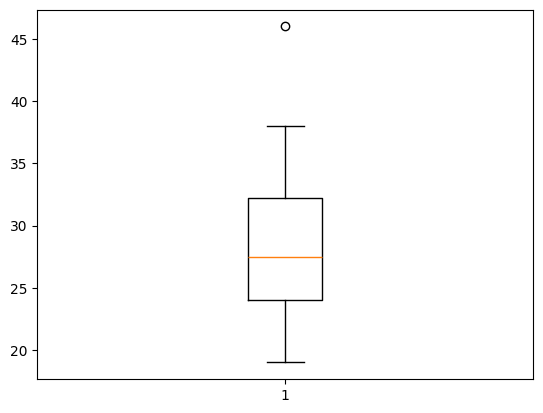

<class 'dict'>
dict_keys(['whiskers', 'caps', 'boxes', 'medians', 'fliers', 'means'])
[<matplotlib.lines.Line2D object at 0x000001D745F8A210>, <matplotlib.lines.Line2D object at 0x000001D745F8A350>]
[24. 19.]
[32.25 38.  ]


In [90]:
age = [19,20,23,46,21,25,26,25,28,31,37,24,28,34,38,33,32,29,27,24]
box1 = plt.boxplot(age)
plt.show()

print(type(box1))
print(box1.keys())
print('='*50)
print(box1['whiskers'])
print(box1['whiskers'][0].get_ydata())      # 아래쪽 수염의 max, min
print(box1['whiskers'][1].get_ydata())      # 위쪽 수염의 max, min

**<연습문제>**

[문1] titanic의 Age와 Fare에 대해서 각각 박스 플롯을 그리고 해석해 봅시다.

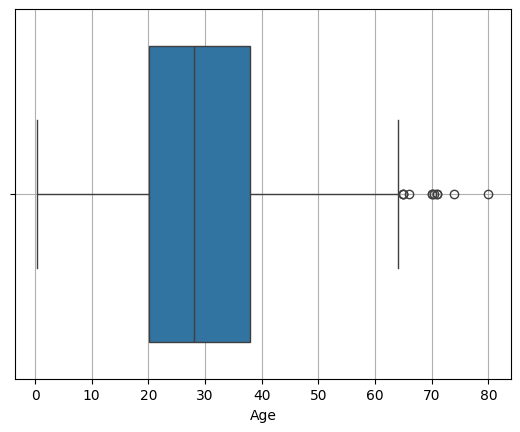

In [91]:
sns.boxplot(x='Age', data=titanic)
plt.grid()
plt.show()

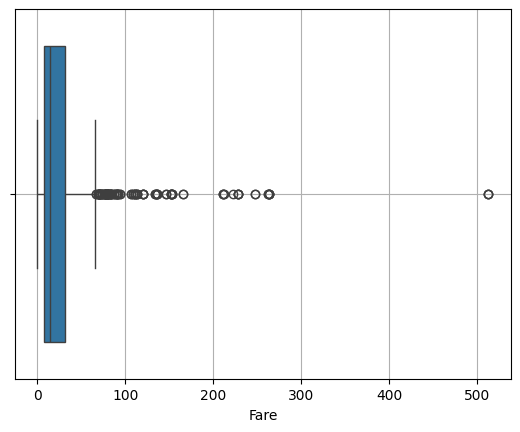

In [92]:
sns.boxplot(x='Fare', data=titanic)
plt.grid()
plt.show()

**4) 시계열 데이터 시각화**

* 시계열 데이터는 보통 시간 축(x축)에 맞게 값들을 라인차트로 표현한다.

In [93]:
air.info()

<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ozone    153 non-null    int64  
 1   Solar.R  146 non-null    float64
 2   Wind     153 non-null    float64
 3   Temp     153 non-null    int64  
 4   Date     153 non-null    str    
dtypes: float64(2), int64(2), str(1)
memory usage: 6.1 KB


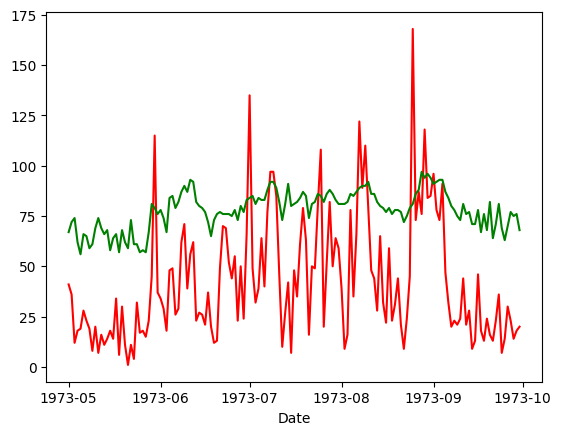

In [94]:
air['Date'] = pd.to_datetime(air['Date'])       # 날짜형식으로 변환

plt.plot('Date', 'Ozone', 'r-', data=air, label='Ozone')        # 패턴 비교(Ozone, Temp)를 y축으로 비교
plt.plot('Date', 'Temp', 'g-', data=air, label='Temp')

plt.xlabel('Date')
plt.show()

## 1.3.범주형 변수

### 1.3.1. 수치화 : 기초통계량

- 범주형 변수는 범주별 빈도수와 비율을 확인한다.
- 리스트.count(‘값’)
    - 해당 값이 몇 개 있는지 count 한다.
    - Count를 전체 개수(len(gender))로 나눠주면 비율이 된다.
    - 그런데, 범주가 두 세 개 정도면, 이렇게 계산하는 게 가능하다.
    - 하지만, 만약 범주가 20개라면?


**1) 범주별 빈도수**

- .value_counts() : 범주의 개수와 상관없이 범주 별 개수를 count 한다.

In [95]:
titanic['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

**2) 범주별 비율**

- .value_counts()를 전체 데이터 건수로 나눠준다.

In [96]:
# 전체 데이터 건수 : .shape의 첫번째 값
print(titanic.shape)
print(titanic.shape[0])

(891, 8)
891


데이터프레임의 행, 열의 수를 세는 다양한 방법 : https://rfriend.tistory.com/450

In [97]:
titanic['Pclass'].value_counts() / titanic.shape[0]

Pclass
3    0.551066
1    0.242424
2    0.206510
Name: count, dtype: float64

* titanic['Pclass’] 해석
    * .value_counts()를 이용하여 범주별 빈도수와 범주별 비율을 구할 수 있다.
    * 3등급 객실 탑승객이 전체에서 55%를 차지한다.
    * 1등급 객실이 24%, 2등급 객실이 20.7 %



**<연습문제>**

[문1] titanic의 Embarked에 대한 기초 통계량을 구하시오.

In [144]:
titanic[['Embarked']].describe().T

,count,unique,top,freq
Embarked,889,3,Southampton,644


[문2] titanic의 Survived에 대한 기초 통계량을 구하시오.

In [99]:
titanic[['Survived']].describe().T

,count,mean,std,min,25%,50%,75%,max
Survived,891.0,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0


In [148]:
titanic['Embarked'].value_counts()

Embarked
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

In [100]:
# 범주별 빈도
print(titanic[['Survived']].value_counts())

# 범주별 비율
print(titanic[['Survived']].value_counts()/titanic.shape[0]*100)


Survived
0           549
1           342
Name: count, dtype: int64
Survived
0           61.616162
1           38.383838
Name: count, dtype: float64


In [ ]:
print(titanic[['count']].value_counts()/titanic.shape[0]*100)

Age  
24.00    3.367003
22.00    3.030303
18.00    2.918070
28.00    2.805836
19.00    2.805836
           ...   
24.50    0.112233
0.67     0.112233
0.42     0.112233
34.50    0.112233
74.00    0.112233
Name: count, Length: 88, dtype: float64


### 1.3.2. 시각화

**1) bar chart**

* seaborn의 countplot
    * plt.bar() 를 이용하려면 먼저 집계한 후 결과를 가지고 그래프를 그려야 한다.
    * countplot은 집계 + bar plot을 한꺼번에 해결해준다.

In [101]:
titanic['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

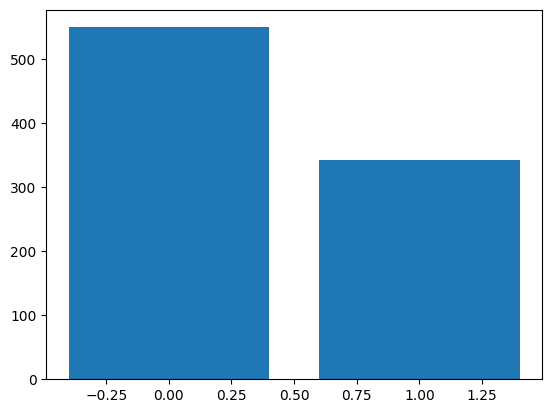

In [ ]:
pclass_count = titanic['Pclass'].value_counts()

plt.bar(pclass_count.index, pclass_count.values)
plt.show()

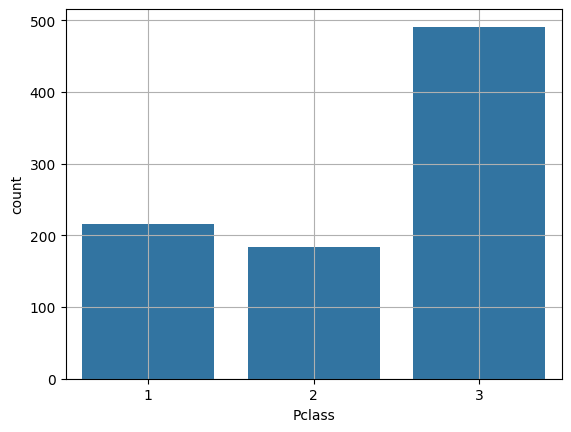

In [103]:
sns.countplot(x='Pclass', data=titanic)
plt.grid()
plt.show()

**<연습문제>**

[문1] titanic의 Embarked에 대한 bar chart를 그리시오.

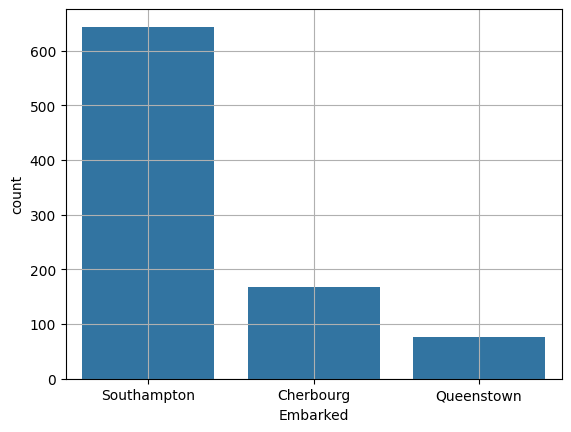

In [104]:
sns.countplot(x='Embarked', data=titanic)
plt.grid()
plt.show()

**2) pie chart**

* 범주별 비율 비교할 때 파이차트 사용
* 역시 먼저 집계를 해야 한다.
* plt.pie( 값, labels=범주이름, autopct = ‘%.2f%%’)
    * autopct = ‘%**.2f%**%’ : 그래프에 표시할 값 비율 값에 대한 설정이다.
        * **.2f%** : 소수점 두 자리 퍼센트로 표기 한다는 의미


* pie chart 기본

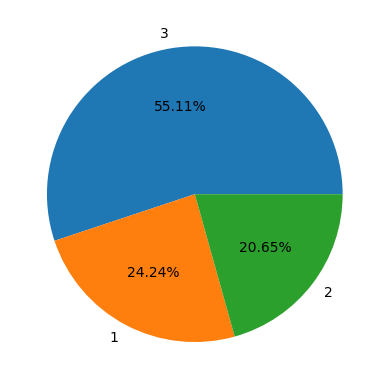

In [126]:
temp = titanic['Pclass'].value_counts()

plt.pie(
    temp.values,                # 각 조각의 비율을 결정하는 값
    labels=temp.index,          # 각 조각에 표시될 라벨
    autopct='%.2f%%'            # 각 조각에 비율을 표시(소수점 2자리)
)
plt.show()

* pie chart 꾸미기 1

    * 각도와 방향 조정
        * startangle = 90 : 90도 부터 시작
        * counterclock = False : 시계 방향으로

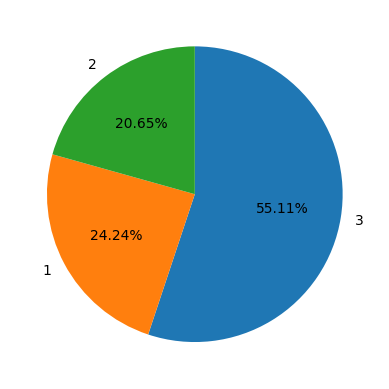

In [122]:
plt.pie(
    temp.values,                
    labels=temp.index,         
    autopct='%.2f%%',
    startangle=90,
    counterclock=False            
)
plt.show()

* pie chart 꾸미기 2

    * 간격 띄우고, 그림자 넣기
        * explode = [0.05, 0.05,0.05] : 중심으로 부터 1,2,3 을 얼마만큼 띄울지
        * shadow = True : 그림자 추가



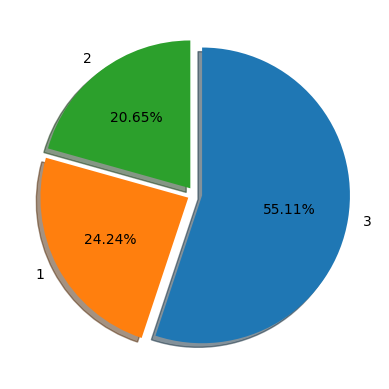

In [123]:
plt.pie(
    temp.values,                
    labels=temp.index,         
    autopct='%.2f%%',
    startangle=90,
    counterclock=False,
    explode=[0.05, 0.05, 0.05],
    shadow=True    
)
plt.show()

**<연습문제>**

[문1] titanic의 Embarked에 대한 pie chart를 그리시오.
* 소수점 1자리까지 비율(%)를 표시하시오.

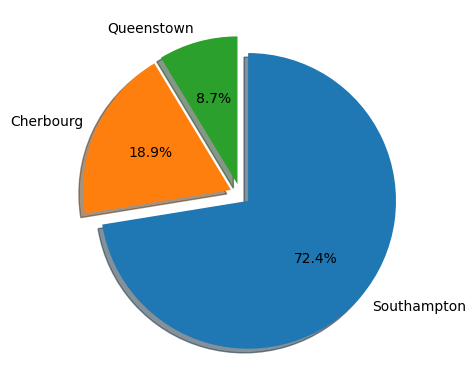

In [127]:
temp2 = titanic['Embarked'].value_counts()

plt.pie(
    temp2.values,
    labels = temp2.index,   
    autopct = '%.1f%%',     
    startangle=90,
    counterclock=False,
    explode = [0.07, 0.07, 0.07],
    shadow=True)
plt.show()

## 1.4.종합 연습문제

- 라이브러리 불러오기

In [136]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

**보스톤 집값 데이터 변수설명**
> * medv  : 1978 보스턴 주택 가격, 506개 타운의 주택 가격 중앙값 (단위 1,000 달러) <== Target
* crim	범죄율
* zn	25,000 평방피트를 초과 거주지역 비율
* indus	비소매상업지역 면적 비율
* chas	찰스강변 위치(범주 : 강변1, 아니면 0)
* nox	일산화질소 농도
* rm	주택당 방 수
* age	1940년 이전에 건축된 주택의 비율
* dis	직업센터의 거리
* rad	방사형 고속도로까지의 거리
* tax	재산세율
* ptratio	학생/교사 비율
* lstat	인구 중 하위 계층 비율


In [128]:
# 보스톤 집값 데이터: boston.csv
df = pd.read_csv('./data/boston.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [129]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  lstat    506 non-null    float64
 12  medv     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


In [130]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


### 1.4.1. 숫자형 변수

* medv(집값)

In [155]:
def eda_1_n(data, var, bins=30):
    # 기초통계량
    display(data[[var]].describe().T)

    # 시각화
    plt.figure(figsize=(10,8))

    # 히스토그램
    plt.subplot(2,1,1)
    sns.histplot(x=var, data=data, bins=bins, kde=True)
    plt.grid()

    # 박스플롯
    plt.subplot(2,1,2)
    sns.boxplot(x=var, data=data)
    plt.grid()

    plt.show()

In [131]:
# 기초통계량
df[['medv']].describe().T

,count,mean,std,min,25%,50%,75%,max
medv,506.0,22.532806,9.197104,5.0,17.025,21.2,25.0,50.0


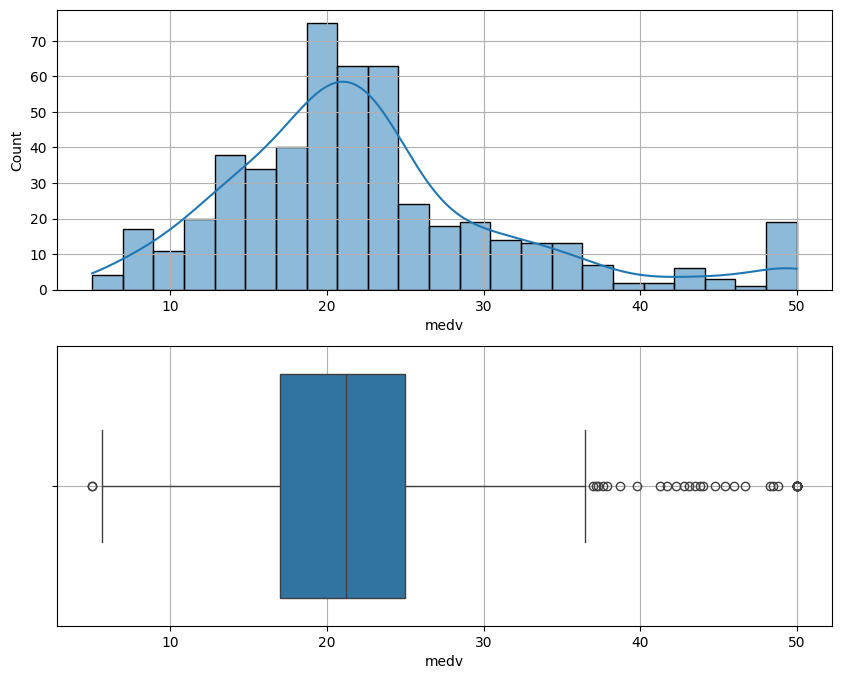

In [133]:
# 시각화
plt.figure(figsize=(10,8))

# 히스토그램
plt.subplot(2,1,1)
sns.histplot(x='medv', data=df, kde=True)
plt.grid()

# 박스플롯
plt.subplot(2,1,2)
sns.boxplot(x='medv', data=df)
plt.grid()

plt.show()


* crim(범죄율)

In [149]:
df[['crim']].head()

,crim
0,0.00632
1,0.02731
2,0.02729
3,0.03237
4,0.06905


In [150]:
# 기초통계량
df[['crim']].describe()

,crim
count,506.000000
mean,3.613524
std,8.601545
min,0.006320
25%,0.082045
50%,0.256510
75%,3.677083
max,88.976200


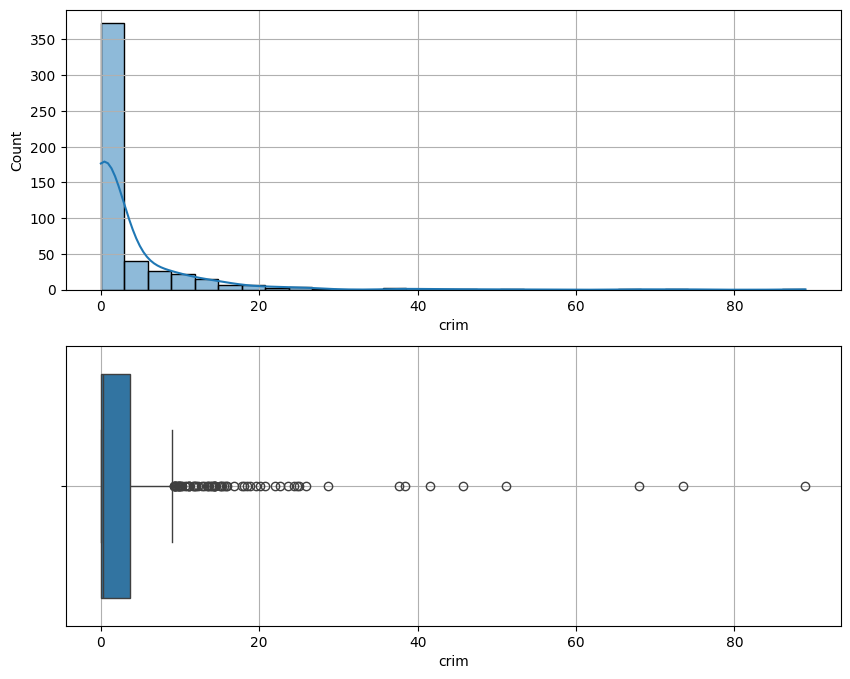

In [151]:
# 시각화
plt.figure(figsize=(10,8))

# 히스토그램
plt.subplot(2,1,1)
sns.histplot(x='crim', data=df, bins=30, kde=True)
plt.grid()

# 박스플롯
plt.subplot(2,1,2)
sns.boxplot(x='crim', data=df)
plt.grid()

plt.show()

* lstat(하위계층 비율)

,count,mean,std,min,25%,50%,75%,max
lstat,506.0,12.653063,7.141062,1.73,6.95,11.36,16.955,37.97


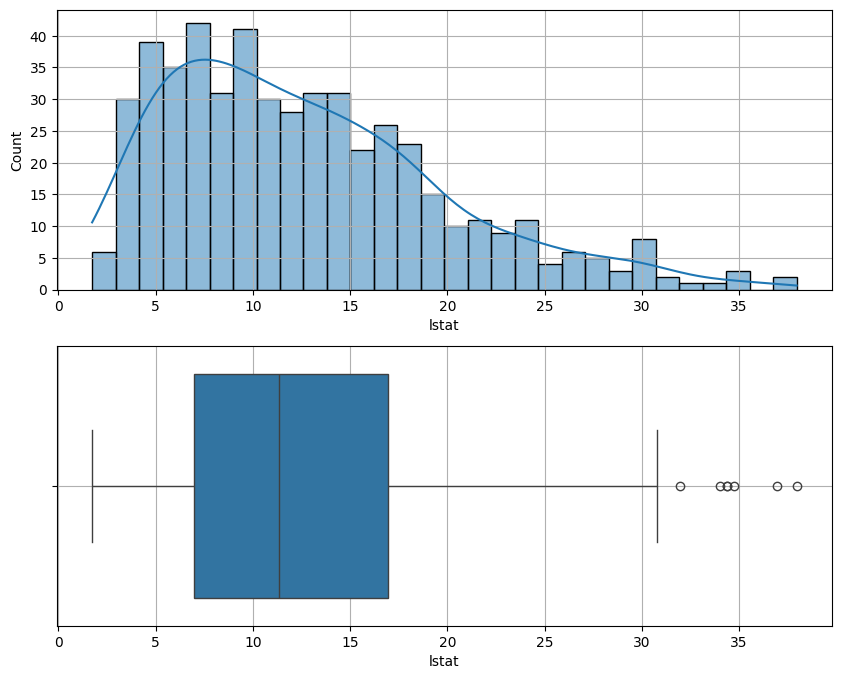

In [158]:
var = 'lstat'
eda_1_n(df, var)

In [110]:
# 기초통계량


In [111]:
# 시각화


* ptratio(교사1명당 학생수)

,count,mean,std,min,25%,50%,75%,max
ptratio,506.0,18.455534,2.164946,12.6,17.4,19.05,20.2,22.0


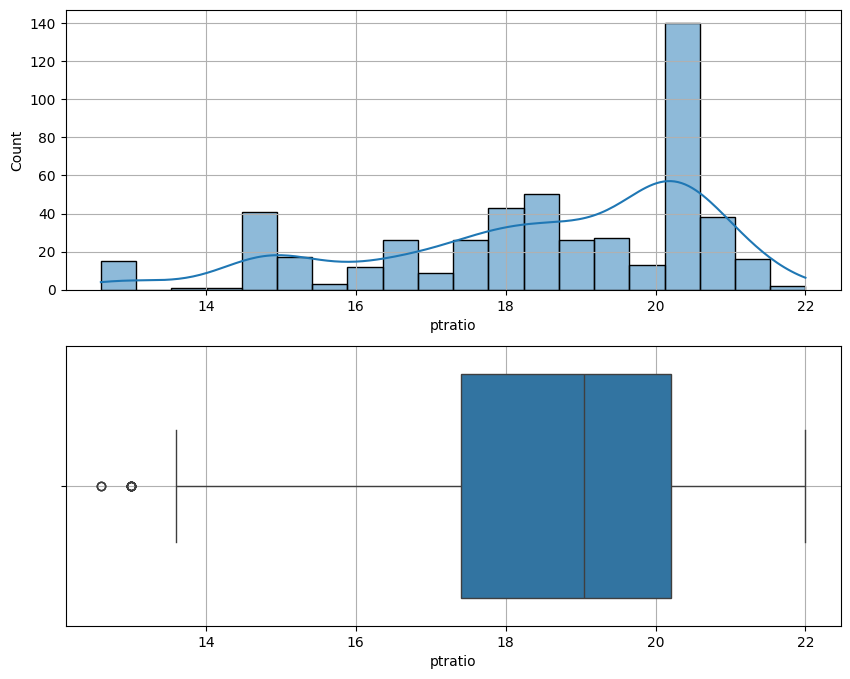

In [161]:
var = 'ptratio'
eda_1_n(df, var, bins=20)

In [112]:
# 기초통계량


In [113]:
# 시각화


* tax(재산세율)

,count,mean,std,min,25%,50%,75%,max
tax,506.0,408.237154,168.537116,187.0,279.0,330.0,666.0,711.0


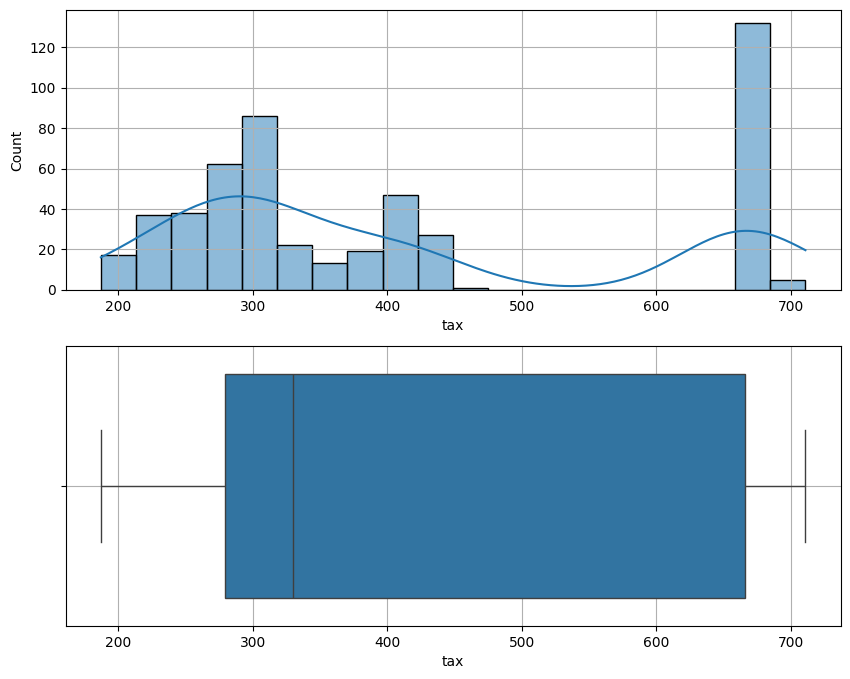

In [162]:
var = 'tax'
eda_1_n(df, var, bins=20)

In [114]:
# 기초통계량


In [115]:
# 시각화


- 단변량 분석 코드를 함수로 만들기(중요!)
    - 복잡하고 반복적인 코드를 함수로 만들어서 사용해 봅시다.

### 1.4.2. 범주형 변수

* chas(찰스강변 여부)

In [163]:
# 기초통계량
display(df['chas'].value_counts())

chas
0    471
1     35
Name: count, dtype: int64

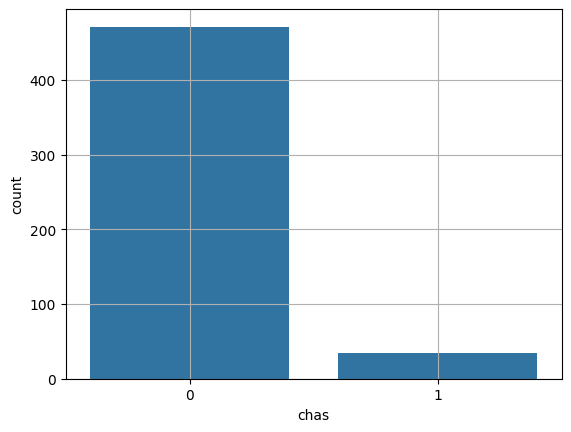

In [164]:
# 시각화
sns.countplot(x=df['chas'])
plt.grid()
plt.show()

* 단변량 분석 코드를 함수로 만들기(중요!)
    * 복잡하고 반복적인 코드를 함수로 만들어서 사용해 봅시다.

In [165]:
def dea_1_c(data, var):
    # 기초통계량
    display(df['chas'].value_counts())

    # 시각화
    sns.countplot(x=df['chas'])
    plt.grid()
    plt.show()

chas
0    471
1     35
Name: count, dtype: int64

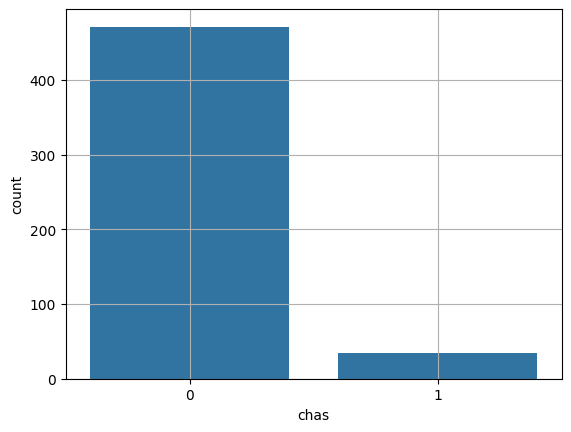

In [166]:
dea_1_c(df, 'chas')